# Notebook 4 Univariate Analysis

**Telecom Customer Churn Dataset**

**Univariate analysis** is the simplest form of statistical data analysis that examines just one variable at a time.


## 1. Setup and Data Load

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
df = pd.read_csv('telecom_customer_churn.csv')
print("Shape:", df.shape)
df.head()

Shape: (1015, 14)


,customer_id,gender,senior_citizen,partner,dependents,tenure_months,phone_service,internet_service,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,CUST-10681,Male,0,Yes,No,24.0,Yes,Fiber optic,Month-to-month,Yes,Credit card,80.04,1900.19,No
1,CUST-10024,Female,0,Yes,No,35.0,Yes,Fiber optic,Month-to-month,Yes,Mailed check,42.99,1539.83,No
2,CUST-10621,Male,0,Yes,No,68.0,Yes,DSL,Month-to-month,Yes,Electronic check,79.31,5401.35,Yes
3,CUST-10099,Male,0,Yes,Yes,18.0,Yes,Fiber optic,Month-to-month,Yes,Electronic check,113.02,2022.80,No
4,CUST-10284,Male,1,Yes,Yes,34.0,Yes,No,Month-to-month,No,Electronic check,28.78,966.99,Yes


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1015 entries, 0 to 1014
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        1015 non-null   str    
 1   gender             1015 non-null   str    
 2   senior_citizen     1015 non-null   int64  
 3   partner            1015 non-null   str    
 4   dependents         1015 non-null   str    
 5   tenure_months      1005 non-null   float64
 6   phone_service      1015 non-null   str    
 7   internet_service   995 non-null    str    
 8   contract           1015 non-null   str    
 9   paperless_billing  1015 non-null   str    
 10  payment_method     1000 non-null   str    
 11  monthly_charges    1015 non-null   float64
 12  total_charges      985 non-null    float64
 13  churn              1015 non-null   str    
dtypes: float64(3), int64(1), str(10)
memory usage: 168.7 KB


## 2. Data Quality Check

**Purpose:** identify missing values, duplicates, and invalid values that could distort the univariate statistics before interpreting them.

In [21]:
print("Missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("Fully duplicated customer_id count:", df['customer_id'].duplicated().sum())
print("Rows with negative monthly_charges:", (df['monthly_charges'] < 0).sum())
for c in ['gender', 'partner', 'paperless_billing']:
    print(f"{c}: {sorted(df[c].dropna().unique())}")

Missing values per column:
tenure_months       10
internet_service    20
payment_method      15
total_charges       30
dtype: int64
Fully duplicated customer_id count: 15
Rows with negative monthly_charges: 3
gender: ['F', 'Female', 'M', 'Male', 'female', 'male']
partner: ['N', 'No', 'Y', 'Yes', 'no', 'yes']
paperless_billing: ['N', 'No', 'Y', 'Yes', 'no', 'yes']


**Findings**

**Missing values** exist in `tenure_months`, `internet_service`, `payment_method`, and `total_charges`. These are kept as `NaN` and excluded pairwise in the statistics below.

**Duplicate records:** 15 `customer_id` values appear twice as exact duplicate rows.

**Invalid values:** 3 rows have a negative `monthly_charges`, which is not physically possible and is almost certainly a data entry error.

**Inconsistent labels:** `gender`, `partner`, and `paperless_billing` contain mixed casing such as `Yes`, `yes`, `Y`. These are standardized below for accurate frequency counts.

In [22]:
df['gender'] = df['gender'].str.strip().str.lower().map({'male': 'Male', 'm': 'Male', 'female': 'Female', 'f': 'Female'})
for c in ['partner', 'dependents', 'phone_service', 'paperless_billing']:
    df[c] = df[c].astype(str).str.strip().str.lower().map({'yes': 'Yes', 'y': 'Yes', 'no': 'No', 'n': 'No'})
print("Standardized. New unique values:")
for c in ['gender', 'partner', 'paperless_billing']:
    print(f"{c}: {sorted(df[c].dropna().unique())}")

Standardized. New unique values:
gender: ['Female', 'Male']
partner: ['No', 'Yes']
paperless_billing: ['No', 'Yes']


## 3. Numerical Variables

**Columns analyzed:** `tenure_months`, `monthly_charges`, `total_charges`. `senior_citizen` is a binary flag and is treated as categorical in Section 4.

In [23]:
num_cols = ['tenure_months', 'monthly_charges', 'total_charges']
def numeric_summary(series, name):
    s = series.dropna()
    summary = {
        'Count': s.count(),
        'Missing': series.isnull().sum(),
        'Mean': s.mean(),
        'Median': s.median(),
        'Mode': s.mode().iloc[0] if not s.mode().empty else np.nan,
        'Min': s.min(),
        'Max': s.max(),
        'Range': s.max() - s.min(),
        'Variance': s.var(),
        'Std Dev': s.std(),
        'Q1': s.quantile(0.25),
        'Q3': s.quantile(0.75),
        'IQR': s.quantile(0.75) - s.quantile(0.25),
        'P10': s.quantile(0.10),
        'P90': s.quantile(0.90),
        'Skewness': s.skew(),
        'Kurtosis': s.kurt(),
    }
    return pd.Series(summary, name=name)
summary_table = pd.concat([numeric_summary(df[c], c) for c in num_cols], axis=1)
summary_table.round(2)

,tenure_months,monthly_charges,total_charges
Count,1005.00,1015.00,985.00
Missing,10.00,0.00,30.00
Mean,34.26,69.29,2360.99
Median,34.00,70.09,1849.21
Mode,21.00,33.60,0.00
Min,0.00,-97.93,0.00
Max,72.00,119.45,8354.36
Range,72.00,217.38,8354.36
Variance,446.80,907.53,3547920.22
Std Dev,21.14,30.13,1883.59


### 3.1 tenure_months

**Definition:** how long a customer has stayed, in months.

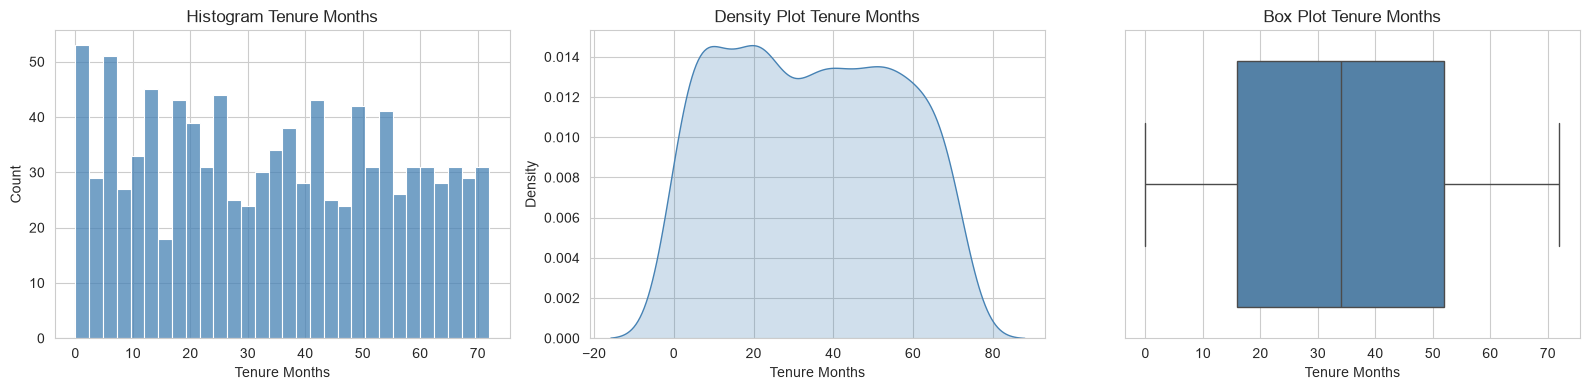

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df['tenure_months'].dropna(), bins=30, kde=False, color='steelblue', ax=axes[0])
axes[0].set_title('Histogram Tenure Months')
axes[0].set_xlabel('Tenure Months')
sns.kdeplot(df['tenure_months'].dropna(), fill=True, color='steelblue', ax=axes[1])
axes[1].set_title('Density Plot Tenure Months')
axes[1].set_xlabel('Tenure Months')
sns.boxplot(x=df['tenure_months'], color='steelblue', ax=axes[2])
axes[2].set_title('Box Plot Tenure Months')
axes[2].set_xlabel('Tenure Months')
plt.tight_layout()
plt.show()

**Findings**

**Range:** spans the full 0 to 72 month range with a mean and median that are close to each other, indicating a roughly symmetric distribution.

**Shape:** the histogram and density plot show a fairly flat, close to uniform spread with a mild bump near 0 months.

**Outliers:** the box plot shows no significant outliers since tenure is naturally bounded.

**Kurtosis:** negative excess kurtosis indicates a platykurtic, flatter than normal shape.

### 3.2 monthly_charges

**Definition:** the recurring monthly bill amount.

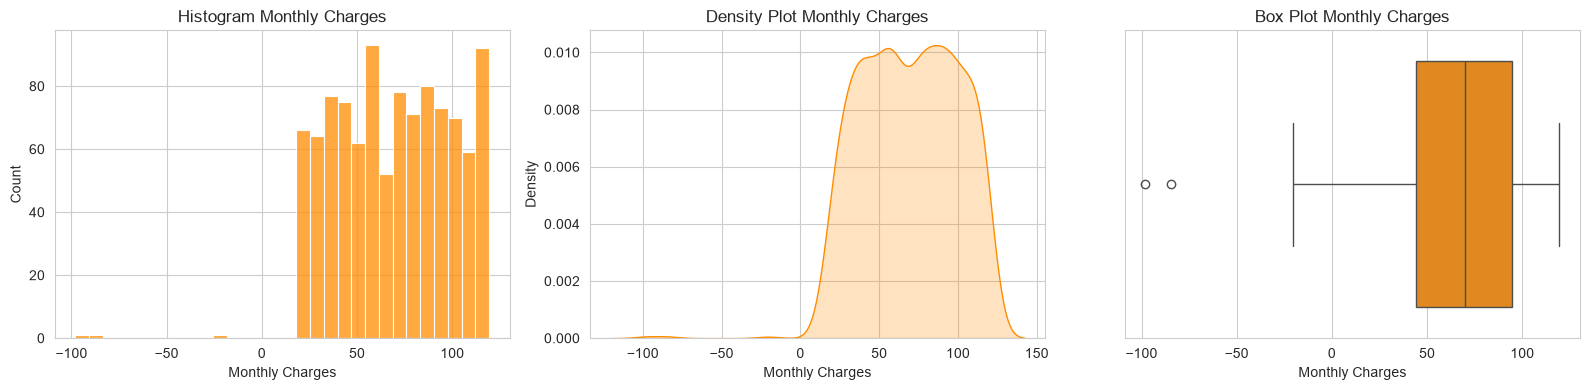

Rows with negative monthly_charges:
    customer_id  monthly_charges
443  CUST-10221           -97.93
782  CUST-10576           -20.30
917  CUST-10130           -84.27


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df['monthly_charges'], bins=30, kde=False, color='darkorange', ax=axes[0])
axes[0].set_title('Histogram Monthly Charges')
axes[0].set_xlabel('Monthly Charges')
sns.kdeplot(df['monthly_charges'], fill=True, color='darkorange', ax=axes[1])
axes[1].set_title('Density Plot Monthly Charges')
axes[1].set_xlabel('Monthly Charges')
sns.boxplot(x=df['monthly_charges'], color='darkorange', ax=axes[2])
axes[2].set_title('Box Plot Monthly Charges')
axes[2].set_xlabel('Monthly Charges')
plt.tight_layout()
plt.show()
print("Rows with negative monthly_charges:")
print(df.loc[df['monthly_charges'] < 0, ['customer_id', 'monthly_charges']])

**Findings**

**Typical range:** most bills fall between roughly 44 dollars and 94 dollars, with a median near 70 dollars close to the mean, indicating a fairly symmetric distribution.

**Invalid outliers:** the box plot flags 3 negative values down to about negative 98 dollars. A monthly charge cannot legitimately be negative, so these are very likely data entry errors.

**Tails:** aside from the invalid points, kurtosis is close to normal or slightly platykurtic.

### 3.3 total_charges

**Definition:** the cumulative amount billed to a customer to date.

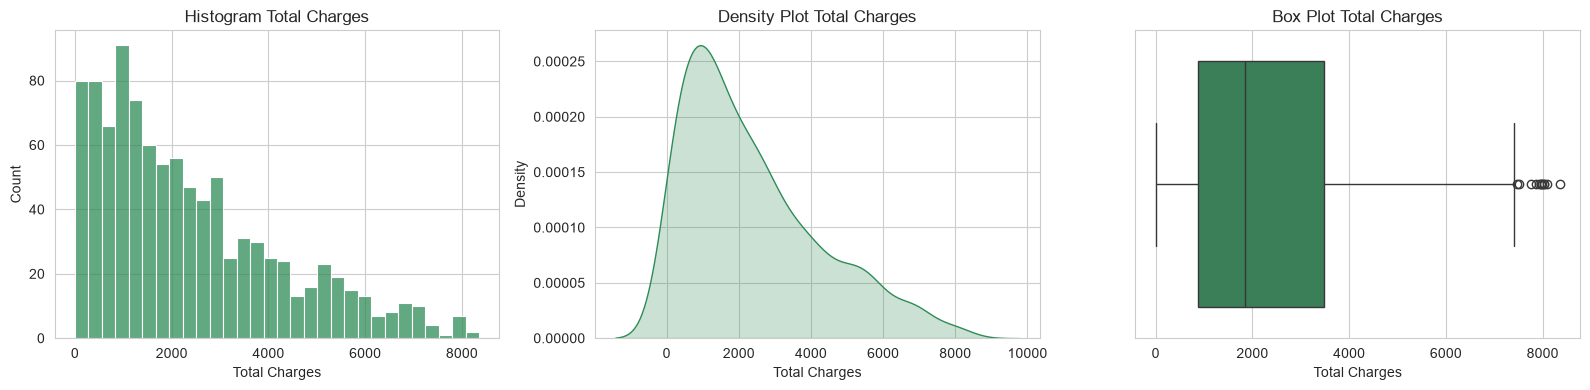

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df['total_charges'].dropna(), bins=30, kde=False, color='seagreen', ax=axes[0])
axes[0].set_title('Histogram Total Charges')
axes[0].set_xlabel('Total Charges')
sns.kdeplot(df['total_charges'].dropna(), fill=True, color='seagreen', ax=axes[1])
axes[1].set_title('Density Plot Total Charges')
axes[1].set_xlabel('Total Charges')
sns.boxplot(x=df['total_charges'], color='seagreen', ax=axes[2])
axes[2].set_title('Box Plot Total Charges')
axes[2].set_xlabel('Total Charges')
plt.tight_layout()
plt.show()

**Findings**

**Skewness:** this is the most right skewed of the three numerical variables. The mean sits noticeably above the median, pulled up by a smaller group of long tenure, high spend customers.

**Explanation:** total charges accumulates over tenure months multiplied by monthly charges, so long tenure customers naturally stretch the right tail.

**Outliers:** the box plot shows a long upper tail but no implausible values, unlike monthly charges.

**Best summary statistic:** because of the right skew, the median is a more representative typical value than the mean for this variable.

## 4. Categorical Variables

**Columns analyzed:** `gender`, `senior_citizen`, `partner`, `dependents`, `phone_service`, `internet_service`, `contract`, `paperless_billing`, `payment_method`, `churn`.

In [27]:
cat_cols = ['gender', 'senior_citizen', 'partner', 'dependents', 'phone_service', 'internet_service', 'contract', 'paperless_billing', 'payment_method', 'churn']
for c in cat_cols:
    print(f"{c}")
    print("Unique values:", df[c].nunique(dropna=True))
    vc = df[c].value_counts(dropna=False)
    pct = df[c].value_counts(normalize=True, dropna=False) * 100
    table = pd.concat([vc, pct.round(2)], axis=1)
    table.columns = ['Count', 'Percentage']
    print(table)

gender
Unique values: 2
        Count  Percentage
gender                   
Female    514       50.64
Male      501       49.36
senior_citizen
Unique values: 2
                Count  Percentage
senior_citizen                   
0                 834       82.17
1                 181       17.83
partner
Unique values: 2
         Count  Percentage
partner                   
No         509       50.15
Yes        506       49.85
dependents
Unique values: 2
            Count  Percentage
dependents                   
No            700       68.97
Yes           315       31.03
phone_service
Unique values: 2
               Count  Percentage
phone_service                   
Yes              916       90.25
No                99        9.75
internet_service
Unique values: 3
                  Count  Percentage
internet_service                   
Fiber optic         431       42.46
DSL                 389       38.33
No                  175       17.24
NaN                  20        1.97
contract
U

### 4.1 churn

**Role:** the target variable.

C:\Users\hemak\AppData\Local\Temp\ipykernel_11648\2766911884.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df, palette=['#4C72B0', '#DD8452'], ax=axes[0])


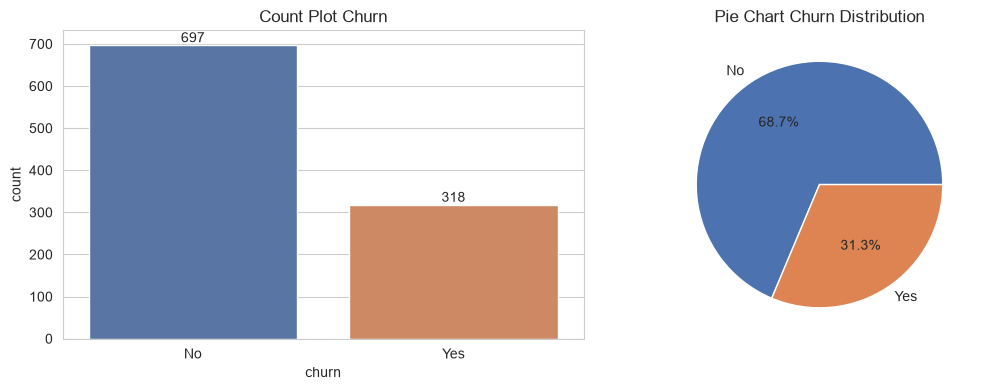

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x='churn', data=df, palette=['#4C72B0', '#DD8452'], ax=axes[0])
axes[0].set_title('Count Plot Churn')
for p in axes[0].patches:
    axes[0].annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')
df['churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'], ax=axes[1], ylabel='')
axes[1].set_title('Pie Chart Churn Distribution')
plt.tight_layout()
plt.show()

**Findings**

**Proportion:** roughly 1 in 4 customers, about 25 to 27 percent, have churned, indicating a moderately imbalanced target.

**Modeling implication:** this imbalance matters for classification modeling since accuracy alone would be a misleading metric.

### 4.2 contract

**Definition:** the type of service contract held by the customer.

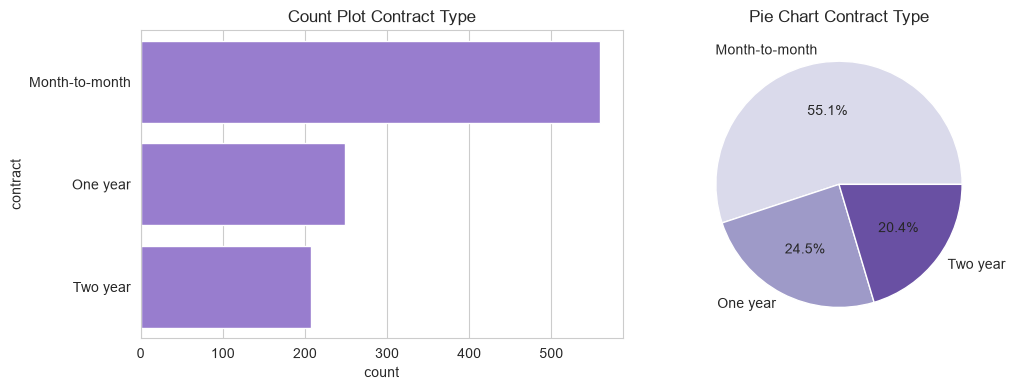

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
order = df['contract'].value_counts().index
sns.countplot(y='contract', data=df, order=order, color='mediumpurple', ax=axes[0])
axes[0].set_title('Count Plot Contract Type')
df['contract'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1], ylabel='', colors=sns.color_palette('Purples', 3))
axes[1].set_title('Pie Chart Contract Type')
plt.tight_layout()
plt.show()

**Findings**

**Dominant category:** month to month is the dominant contract type, well ahead of one year and two year contracts.

**Risk implication:** month to month customers have no lock in and are historically the most likely to churn.

### 4.3 internet_service, payment_method, phone_service

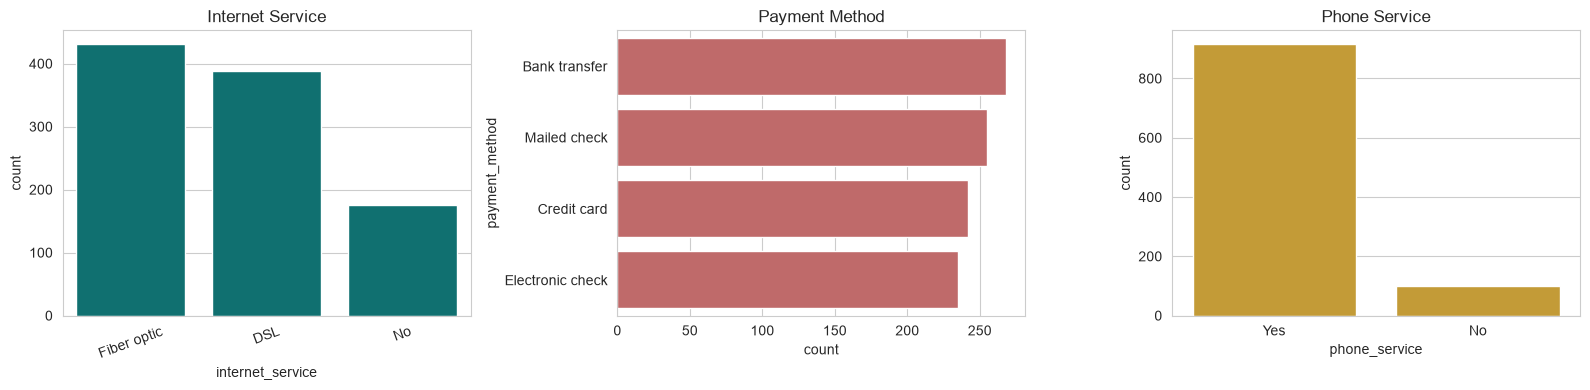

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(x='internet_service', data=df, order=df['internet_service'].value_counts().index, color='teal', ax=axes[0])
axes[0].set_title('Internet Service')
axes[0].tick_params(axis='x', rotation=20)
sns.countplot(y='payment_method', data=df, order=df['payment_method'].value_counts().index, color='indianred', ax=axes[1])
axes[1].set_title('Payment Method')
sns.countplot(x='phone_service', data=df, color='goldenrod', ax=axes[2])
axes[2].set_title('Phone Service')
plt.tight_layout()
plt.show()

**Findings**

**internet_service:** fiber optic and DSL are both common, with a smaller no internet group, and 20 records have a missing value.

**payment_method:** electronic check is the most common method, notably ahead of mailed check, bank transfer, and credit card, with 15 missing values.

**phone_service:** the large majority of customers have phone service, making this a low variance variable with little discriminating power on its own.

### 4.4 Demographic flags

**Columns:** `gender`, `senior_citizen`, `partner`, `dependents`.

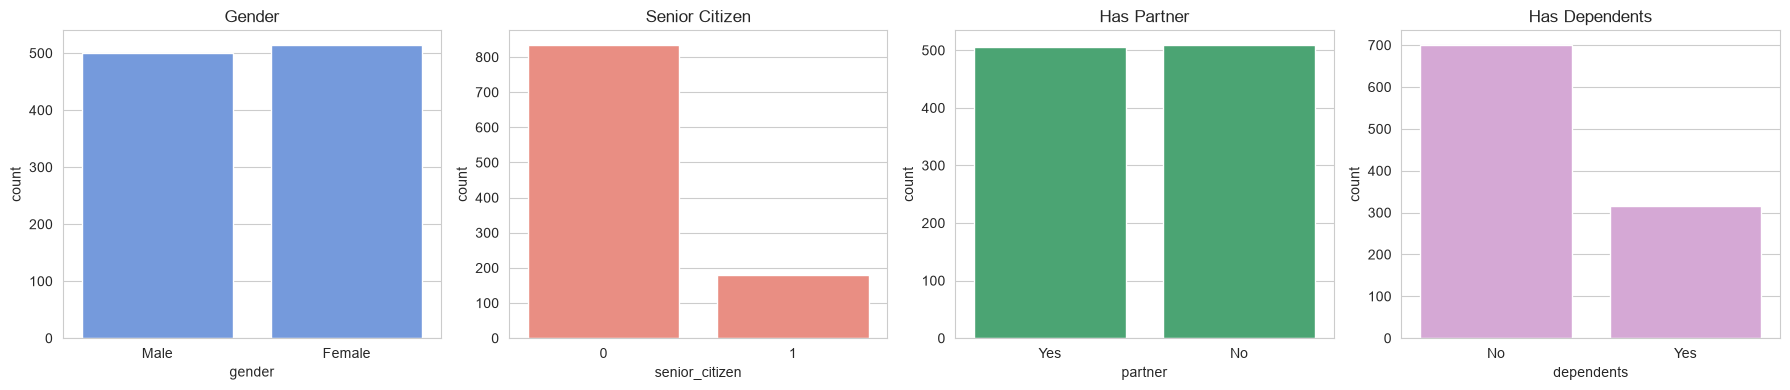

In [31]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
sns.countplot(x='gender', data=df, color='cornflowerblue', ax=axes[0])
axes[0].set_title('Gender')
sns.countplot(x='senior_citizen', data=df, color='salmon', ax=axes[1])
axes[1].set_title('Senior Citizen')
sns.countplot(x='partner', data=df, color='mediumseagreen', ax=axes[2])
axes[2].set_title('Has Partner')
sns.countplot(x='dependents', data=df, color='plum', ax=axes[3])
axes[3].set_title('Has Dependents')
plt.tight_layout()
plt.show()

**Findings**

**gender:** close to an even split, not a strongly discriminating variable by itself.

**senior_citizen:** heavily imbalanced, only about 18 percent of customers are senior citizens.

**partner:** close to evenly split between yes and no.

**dependents:** skews toward no, most customers in this dataset do not have dependents.